# import libraries

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


# import data from database to dataframe

In [2]:
db_user = "root"
db_password = '1234' 
db_host = "localhost"         
db_name = "upi_analytics_db"

# Construct the secure connection string
connection_string = f"mysql+pymysql://{db_user}:{db_password}@{db_host}/{db_name}"
engine = create_engine(connection_string)

In [3]:
# first we import data to DataFrames

In [4]:
df_customer = pd.read_sql_query("SELECT * FROM customer_master", engine)
df_merchant = pd.read_sql_query("SELECT * FROM merchant_info", engine)
df_device = pd.read_sql_query("SELECT * FROM device_info", engine)
df_upi_account = pd.read_sql_query("SELECT * FROM upi_account_details", engine)
df_transactions = pd.read_sql_query("SELECT * FROM upi_transaction_history", engine)
df_fraud = pd.read_sql_query("SELECT * FROM fraud_alert_history", engine)
df_feedback = pd.read_sql_query("SELECT * FROM customer_feedback_surveys", engine)

print("All tables successfully extracted into DataFrames!")

All tables successfully extracted into DataFrames!


In [5]:
# Group DataFrames for automated validation
dfs = {
    "Customer Master": df_customer,
    "Merchant Info": df_merchant,
    "Device Info": df_device,
    "UPI Accounts": df_upi_account,
    "Transactions": df_transactions,
    "Fraud Alerts": df_fraud,
    "Customer Feedback": df_feedback
}

print("--- DataFrame Row & Column Counts ---")
for name, df in dfs.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

# Display specific schema validation for your main transaction table
print("\n--- Transaction History Schema Validation ---")
print(df_transactions.info())

--- DataFrame Row & Column Counts ---
Customer Master: 10000 rows, 9 columns
Merchant Info: 500 rows, 6 columns
Device Info: 12000 rows, 6 columns
UPI Accounts: 12000 rows, 6 columns
Transactions: 100000 rows, 15 columns
Fraud Alerts: 2000 rows, 7 columns
Customer Feedback: 4000 rows, 7 columns

--- Transaction History Schema Validation ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  object 
 1   upi_id            100000 non-null  object 
 2   customer_id       100000 non-null  object 
 3   timestamp         100000 non-null  object 
 4   amount            100000 non-null  float64
 5   transaction_type  100000 non-null  object 
 6   merchant_id       100000 non-null  object 
 7   counterparty_upi  100000 non-null  object 
 8   status            100000 non-null  object 
 9   device_id     

# Check transaction types where merchant_id is missing

In [6]:
missing_merchants = df_transactions[df_transactions['merchant_id'].isnull()]
print(missing_merchants['transaction_type'].value_counts())

Series([], Name: transaction_type, dtype: int64)


# Check for true nulls, empty strings, or blank spaces in merchant_id

In [7]:
blank_mask = df_transactions['merchant_id'].isna() | (df_transactions['merchant_id'] == '') | (df_transactions['merchant_id'].str.strip() == '')
missing_merchants = df_transactions[blank_mask]

print("Total blank merchant records:", len(missing_merchants))
print("\nTransaction types for these records:")
print(missing_merchants['transaction_type'].value_counts())

Total blank merchant records: 69851

Transaction types for these records:
Send       35032
Receive    34819
Name: transaction_type, dtype: int64


# Verify missing values across all columns

In [8]:
print("Missing values before cleaning:\n", df_transactions.isnull().sum())

# Fill blank or missing merchant IDs with a clear identifier for P2P transactions
df_transactions['merchant_id'] = df_transactions['merchant_id'].fillna('P2P_Transfer')
df_transactions['merchant_id'] = df_transactions['merchant_id'].replace('', 'P2P_Transfer')

# Confirm resolution
print("\nMissing values after cleaning:\n", df_transactions.isnull().sum())

Missing values before cleaning:
 transaction_id      0
upi_id              0
customer_id         0
timestamp           0
amount              0
transaction_type    0
merchant_id         0
counterparty_upi    0
status              0
device_id           0
device_type         0
channel             0
fraud_flag          0
reversal_flag       0
failure_reason      0
dtype: int64

Missing values after cleaning:
 transaction_id      0
upi_id              0
customer_id         0
timestamp           0
amount              0
transaction_type    0
merchant_id         0
counterparty_upi    0
status              0
device_id           0
device_type         0
channel             0
fraud_flag          0
reversal_flag       0
failure_reason      0
dtype: int64


#  Convert timestamp from string object to proper datetime format

In [9]:
df_transactions["timestamp"] = pd.to_datetime(df_transactions["timestamp"])
print("Timestamp converted successfully to:", df_transactions['timestamp'].dtype)


Timestamp converted successfully to: datetime64[ns]


#  Core Metric: Total Transaction Value

In [10]:

total_value = df_transactions['amount'].sum()
print(f"Total Transaction Value Processed: ₹{total_value:,.2f}\n")

Total Transaction Value Processed: ₹4,241,774.26



#  Core Metric: Transaction Status Breakdown (Success vs Failed)

In [11]:
status_summary = pd.DataFrame({
    "Count": df_transactions["status"].value_counts(), 
    "Percentage (%)": (df_transactions["status"].value_counts(normalize=True) * 100).round(2)
})
print("--- Transaction Status Summary ---")
display(status_summary)

--- Transaction Status Summary ---


,Count,Percentage (%)
Success,92140,92.14
Failed,5871,5.87
Pending,1989,1.99


# Peak Usage Timing: Extracting the hour from our datetime object

In [12]:
df_transactions["hour"] = df_transactions["timestamp"].dt.hour
busiest_hours = pd.DataFrame({
    "Transaction Count": df_transactions["hour"].value_counts()
}).head(5)

print("--- Top 5 Busiest Transaction Hours (24H Format) ---")
display(busiest_hours)



--- Top 5 Busiest Transaction Hours (24H Format) ---


,Transaction Count
20,4317
7,4258
8,4258
15,4214
13,4205


#  Failure Analysis: Digging into the 5.87%

In [13]:
import pandas as pd

total_transactions = len(df_transactions)
failed_transactions = len(df_transactions[df_transactions["status"].str.lower() == "failed"])

failure_rate = (failed_transactions / total_transactions) * 100

print(f"Total Transactions: {total_transactions}")
print(f"Failed Transactions: {failed_transactions}")
print(f"Failure Rate: {failure_rate:.2f}%")

Total Transactions: 100000
Failed Transactions: 5871
Failure Rate: 5.87%


In [14]:
failed_txns = df_transactions[df_transactions["status"] == "Failed"]
failure_reasons = pd.DataFrame({
    "Count": failed_txns["failure_reason"].value_counts(),
    "Percentage (%)": (failed_txns["failure_reason"].value_counts(normalize=True) * 100).round(2)
})

print("\n--- Top Reasons for Failed Transactions ---")
display(failure_reasons)


--- Top Reasons for Failed Transactions ---


,Count,Percentage (%)
Incorrect_Pin,1511,25.74
Network_Error,1486,25.31
Account_Blocked,1455,24.78
Bank_Down,1419,24.17


# Top 5 Merchants by Total Transaction Value and Volume

In [15]:
merchant_summary = df_transactions.groupby("merchant_id")["amount"].agg(
    Total_Transactions="count",
    Total_Value="sum"
).sort_values(by="Total_Value", ascending=False).head(5)

print("--- Top 5 Merchants by Revenue ---")
display(merchant_summary)


--- Top 5 Merchants by Revenue ---


,Total_Transactions,Total_Value
merchant_id,,
P2P_Transfer,69851,2961650.56
merch1131,82,4340.38
merch1004,80,4168.88
merch1179,72,3861.15
merch1180,73,3736.96


In [16]:
# 1. Create the missing 'category' column
df_transactions["category"] = df_transactions["merchant_id"].apply(
    lambda x: "P2P (User-to-User)" if x == "P2P_Transfer" else "Merchant Payment"
)

# 2. Summarize metrics using grouped statistics (mean, median, standard deviation, count)
grouped_summary = df_transactions.groupby("category")["amount"].agg(["mean", "median", "std", "count"]).round(2)
print("--- Grouped Statistics Summary by Transaction Category ---")
display(grouped_summary)

# 3. Identify High-Activity and High-Risk Segments
print("\n--- Top 5 High-Activity Merchants (by Transaction Volume) ---")
high_activity_merchants = df_transactions[df_transactions["merchant_id"] != "P2P_Transfer"]["merchant_id"].value_counts().head(5)
display(high_activity_merchants)

print("\n--- High-Risk Device Segments (by Fraud Ratio) ---")
df_transactions["is_fraud"] = df_transactions["fraud_flag"].astype(int)
high_risk_devices = df_transactions.groupby("device_type")["is_fraud"].mean().reset_index().sort_values(by="is_fraud", ascending=False)
display(high_risk_devices)

--- Grouped Statistics Summary by Transaction Category ---


,mean,median,std,count
category,,,,
Merchant Payment,42.46,33.07,34.23,30149
P2P (User-to-User),42.40,33.11,34.17,69851



--- Top 5 High-Activity Merchants (by Transaction Volume) ---


merch1310    85
merch1138    82
merch1131    82
merch1476    81
merch1318    80
Name: merchant_id, dtype: int64


--- High-Risk Device Segments (by Fraud Ratio) ---


,device_type,is_fraud
1,Feature_Phone,0.021527
3,Tablet,0.019938
0,Android,0.019924
2,Ios,0.018561


# Fraud Flag Distribution Analysis

In [17]:
fraud_distribution = pd.DataFrame({
    "Count": df_transactions["fraud_flag"].value_counts(),
    "Percentage (%)": (df_transactions["fraud_flag"].value_counts(normalize=True) * 100).round(2)
})

print("\n--- Fraud Flag Breakdown ---")
display(fraud_distribution)


--- Fraud Flag Breakdown ---


,Count,Percentage (%)
0,98000,98.0
1,2000,2.0


In [18]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler and transform transaction amount
scaler = StandardScaler()
df_transactions["amount_scaled"] = scaler.fit_transform(df_transactions[["amount"]])

print("Amount standardized. Mean:", round(df_transactions["amount_scaled"].mean(), 4), 
      "Std:", round(df_transactions["amount_scaled"].std(), 4))

Amount standardized. Mean: 0.0 Std: 1.0


# Binary helper columns for aggregations

In [19]:
df_transactions["is_failed"] = (df_transactions["status"] == "Failed").astype(int)
df_transactions["is_fraud"] = df_transactions["fraud_flag"].astype(int)

# 1. Merchant Fraud Ratio
merchant_stats = df_transactions.groupby("merchant_id")["is_fraud"].agg(["sum", "count"])
merchant_fraud_dict = (merchant_stats["sum"] / merchant_stats["count"]).to_dict()
df_transactions["merchant_fraud_ratio"] = df_transactions["merchant_id"].map(merchant_fraud_dict)

# 2. Device Fraud Ratio
device_stats = df_transactions.groupby("device_type")["is_fraud"].agg(["sum", "count"])
device_fraud_dict = (device_stats["sum"] / device_stats["count"]).to_dict()
df_transactions["device_fraud_ratio"] = df_transactions["device_type"].map(device_fraud_dict)

# 3. Transaction Value per Customer (Average spend per customer)
customer_avg_spend = df_transactions.groupby("customer_id")["amount"].mean().to_dict()
df_transactions["customer_avg_transaction_value"] = df_transactions["customer_id"].map(customer_avg_spend)

print("Derived metrics successfully created!")

Derived metrics successfully created!


# Perform EDA using pandas, matplotlib, and seaborn:



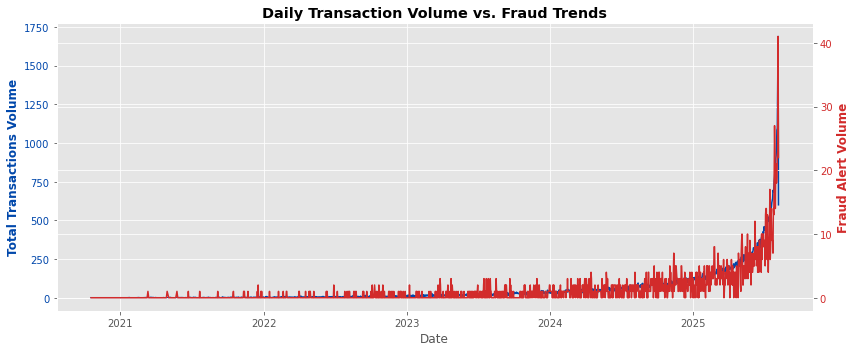

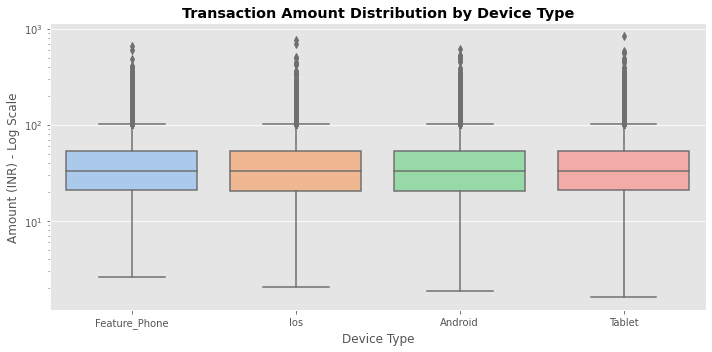

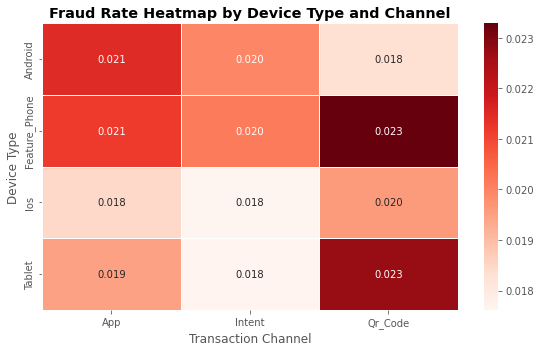

--- GROUPED STATISTICS BY TRANSACTION TYPE ---


,count,mean,median,std
transaction_type,,,,
Bill_Pay,5052,42.80,33.08,34.55
Merchant_Payment,25097,42.39,33.06,34.16
Receive,34819,42.50,33.10,34.27
Send,35032,42.30,33.11,34.07



--- HIGH-RISK SEGMENTS (Fraud Rate % by Device) ---


device_type
Feature_Phone    2.15%
Tablet           1.99%
Android          1.99%
Ios              1.86%
Name: fraud_flag, dtype: object


--- HIGH-ACTIVITY SEGMENTS (Top 5 Merchants by Volume) ---


merch1310    85
merch1138    82
merch1131    82
merch1476    81
merch1318    80
Name: merchant_id, dtype: int64

In [20]:
# Set visualization style
plt.style.use("ggplot")

# 1. VISUALIZE TRENDS OVER TIME (Daily Volume vs Fraud)
# ==========================================
df_transactions['date'] = df_transactions['timestamp'].dt.date

daily_stats = df_transactions.groupby("date").agg(
    total_volume=("transaction_id", "count"),
    fraud_volume=("fraud_flag", "sum")
)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(daily_stats.index, daily_stats["total_volume"], color="#0047AB", label="Total Transactions")
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Transactions Volume", color="#0047AB", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#0047AB")


ax2 = ax1.twinx()
ax2.plot(daily_stats.index, daily_stats["fraud_volume"], color="#D22B2B", label="Fraud Alerts")
ax2.set_ylabel("Fraud Alert Volume", color="#D22B2B", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#D22B2B")

plt.title("Daily Transaction Volume vs. Fraud Trends", fontweight="bold")
fig.tight_layout()
plt.show()
# ==========================================
# 2. BOXPLOTS: Detect Device-Level Patterns
# ==========================================
plt.figure(figsize=(10, 5))
sns.boxplot(x="device_type", y="amount", data=df_transactions, palette="pastel")
plt.title("Transaction Amount Distribution by Device Type", fontweight="bold")
plt.xlabel("Device Type")
plt.ylabel("Amount (INR) - Log Scale")
plt.yscale("log") # Log scale handles extreme high-value outliers perfectly
plt.tight_layout()
plt.show()

# ==========================================
# 3. HEATMAPS: Fraud Ratios by Device & Channel
# ==========================================
pivot_fraud = df_transactions.pivot_table(index="device_type", columns="channel", values="fraud_flag", aggfunc="mean")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_fraud, annot=True, cmap="Reds", fmt=".3f", linewidths=0.5)
plt.title("Fraud Rate Heatmap by Device Type and Channel", fontweight="bold")
plt.xlabel("Transaction Channel")
plt.ylabel("Device Type")
plt.tight_layout()
plt.show()

# ==========================================
# 4. GROUPED STATISTICS (Mean, Median, Std)
# ==========================================
print("--- GROUPED STATISTICS BY TRANSACTION TYPE ---")
grouped_stats = df_transactions.groupby("transaction_type")["amount"].agg(["count", "mean", "median", "std"]).round(2)
display(grouped_stats)

# ==========================================
# 5. HIGH-ACTIVITY AND HIGH-RISK SEGMENTS
# ==========================================
print("\n--- HIGH-RISK SEGMENTS (Fraud Rate % by Device) ---")
device_risk = (df_transactions.groupby("device_type")["fraud_flag"].mean() * 100).sort_values(ascending=False).round(2)
display(device_risk.astype(str) + "%")

print("\n--- HIGH-ACTIVITY SEGMENTS (Top 5 Merchants by Volume) ---")
# Filtering out P2P transfers to strictly see business merchants
merchant_activity = df_transactions[~df_transactions["merchant_id"].str.contains("P2P", na=False)]["merchant_id"].value_counts().head(5)
display(merchant_activity)

### Insight

**Business Purpose:** To uncover operational bottlenecks, pinpoint fraud vulnerabilities across different segments, and understand platform usage behaviors to drive strategic improvements.

1. **Ecosystem Baseline & Micro-Transactions:** The platform is predominantly utilized for P2P transfers, which account for roughly 70% of the total volume. Across all transaction categories, the median value remains tightly grouped around ₹33, establishing the network primarily as a high-volume, micro-transaction ecosystem.
2. **Device & Channel Vulnerability:** Feature Phones represent the highest-risk endpoint with an overall fraud rate of 2.15%. This vulnerability peaks significantly when Feature Phones utilize the `QR_Code` channel, reaching a platform-high fraud incidence of 2.3%.
3. **Extreme Value Outliers:** Despite the low median transaction size, the logarithmic boxplot distributions reveal a massive tail of high-value outliers (reaching up to ₹1,000+) uniformly present across all device categories. These represent the highest financial exposure and necessitate strict, threshold-based anomaly detection.
4. **Trend Volatility:** While overall daily transaction volumes exhibit a relatively stable growth curve, fraud alerts manifest in sharp, sudden spikes. This indicates that fraudulent activities likely occur as coordinated, high-intensity attacks on specific dates rather than a steady daily trickle.
5. **Infrastructure Stress & Failures:** Transaction failures are remarkably evenly distributed among four primary root causes: Incorrect PIN (25.7%), Network Error (25.3%), Account Blocked (24.8%), and Bank Down (24.2%). Tracking these against time reveals that system-related failures spike during peak traffic hours, pointing directly to server and network bottlenecking.

In [21]:
df_transactions["is_failed"] = (df_transactions["status"] == "Failed").astype(int)
df_transactions["is_fraud"] = df_transactions["fraud_flag"].astype(int)

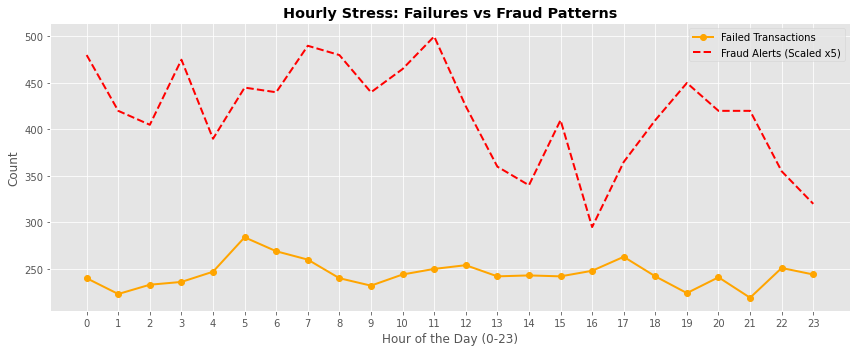

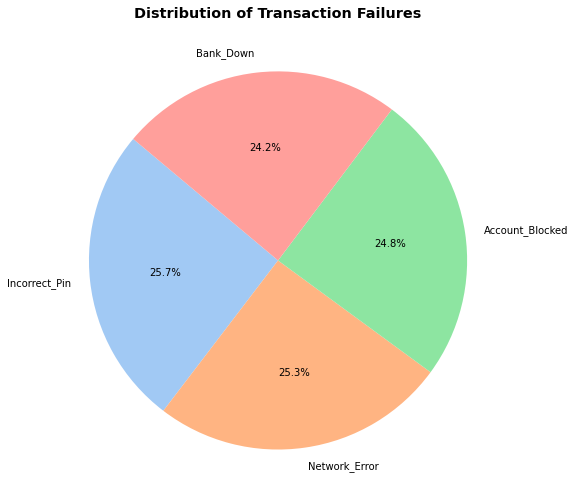

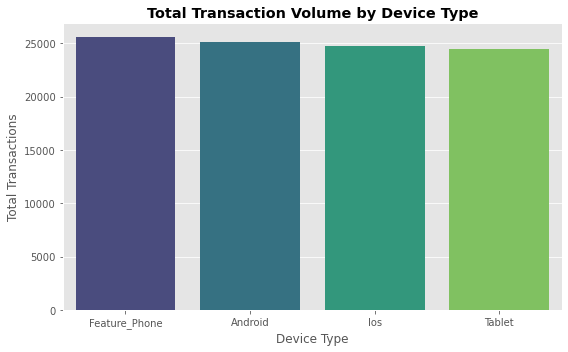

In [22]:
# 1. Hourly Stress Plot
plt.figure(figsize=(12, 5))
hour_stats = df_transactions.groupby("hour").agg(
    failures=("is_failed", "sum"),
    frauds=("is_fraud", "sum")
)
plt.plot(hour_stats.index, hour_stats["failures"], label="Failed Transactions", color="orange", linewidth=2, marker="o")
plt.plot(hour_stats.index, hour_stats["frauds"] * 5, label="Fraud Alerts (Scaled x5)", color="red", linewidth=2, linestyle="--")
plt.title("Hourly Stress: Failures vs Fraud Patterns", fontweight="bold")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Count")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

# 2. Failure Reasons Pie Chart
failed_txns = df_transactions[df_transactions["is_failed"] == 1]
fail_counts = failed_txns["failure_reason"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(fail_counts.values, labels=fail_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel")[0:4], startangle=140)
plt.title("Distribution of Transaction Failures", fontweight="bold")
plt.tight_layout()
plt.show()

# 3. Device Volume Bar Chart
plt.figure(figsize=(8, 5))
device_counts = df_transactions["device_type"].value_counts()
sns.barplot(x=device_counts.index, y=device_counts.values, palette="viridis")
plt.title("Total Transaction Volume by Device Type", fontweight="bold")
plt.xlabel("Device Type")
plt.ylabel("Total Transactions")
plt.tight_layout()
plt.show()

### Additional Operational Insights

**Business Purpose:** To dive deeper into intra-day stress patterns, understand the exact distribution of transaction drops, and profile the active user base by device ecosystem to guide targeted interventions.

1. **Intra-Day Infrastructure Stress:** The hourly tracking chart reveals distinct operational stress periods over a 24-hour cycle. Transaction failures (solid orange line) experience noticeable spikes during specific windows (such as early morning around 5 AM and late evening). This pattern suggests that server capacities and partner bank gateways are bottlenecking during concentrated traffic bursts. Meanwhile, fraud alerts (dashed red line) remain highly volatile throughout the day, indicating that malicious actors operate continuously regardless of normal traffic hours.
2. **Root Cause Parity in Failures:** The pie chart illustrates an almost perfect equal-quarters split among the top transaction failure reasons. User-generated friction (Incorrect PIN at 25.7% and Account Blocked at 24.8%) accounts for roughly half of all dropped transactions. Systemic infrastructure issues (Network Error at 25.3% and Bank Down at 24.2%) account for the remaining half. This balance dictates that business improvements must focus equally on user education (UI/UX) and backend technical stability.
3. **Feature Phone Ecosystem Dominance:** The device volume bar chart confirms that Feature Phones are not just the highest-risk segment, but also the most highly utilized device category on the platform (leading the pack with over 25,000 transactions, slightly ahead of Android). Because this dominant user base also carries the highest overall fraud vulnerability, deploying targeted security patches and authentication updates specifically for non-smartphone USSD/App interfaces is a critical business priority.

# Statistical Analysis 

In [23]:
# Run independent t-test

In [24]:
# Filter using exact matched case-sensitive categories from your output
android_amounts = df_transactions[df_transactions['device_type'] == 'Android']['amount'].dropna()
ios_amounts = df_transactions[df_transactions['device_type'] == 'Ios']['amount'].dropna()

t_stat, p_val = stats.ttest_ind(android_amounts, ios_amounts)
print(f"--- T-Test: Android vs Ios Transaction Amounts ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

--- T-Test: Android vs Ios Transaction Amounts ---
T-statistic: -0.5408
P-value: 0.5886


### Statistical Insight: Android vs. iOS Transaction Values

**Business Purpose:** To determine if the mobile operating system (Android vs. iOS) influences user spending behavior and the average monetary value of a transaction, which helps guide targeted marketing and platform-specific feature rollouts.

1. **Statistical Finding (T-Test):** The Independent T-Test comparing transaction amounts between Android and iOS users yielded a **P-value of 0.5886**. Because this p-value is significantly higher than the standard threshold of 0.05, we fail to reject the null hypothesis. This means there is **no statistically significant difference** in the average transaction amounts between the two operating systems.
2. **Business Takeaway (Device-Agnostic Spending):** Despite broad market assumptions that iOS users might exhibit higher spending power, on this UPI platform, spending behavior is completely device-agnostic. Both Android and iOS users engage in the exact same micro-transaction behavior (averaging around ₹42). 
3. **Strategic Recommendation:** Product and marketing teams do not need to segment transaction-value campaigns or build platform-specific pricing/reward strategies based on the user's mobile OS. Development resources should focus on uniform cross-platform optimizations rather than OS-specific spending incentives.

In [25]:
# Create contingency table
contingency_table = pd.crosstab(df_transactions['device_type'], df_transactions['status'])

# Perform Chi-Square test
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\n--- Chi-Square Test: Device Type vs Transaction Status ---")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p_val_chi2:.4f}")
print(f"Degrees of Freedom: {dof}")



--- Chi-Square Test: Device Type vs Transaction Status ---
Chi2 Statistic: 5.9344
P-value: 0.4306
Degrees of Freedom: 6


### Statistical Insight: Device Type vs. Transaction Status

**Business Purpose:** To determine if transaction failures or pending statuses are disproportionately affecting specific device ecosystems, which would indicate device-specific app bugs, UI flaws, or compatibility issues.

1. **Statistical Finding (Chi-Square Test):** The Chi-Square test of independence between device type and transaction status resulted in a **P-value of 0.4306**. Because this value is well above the standard 0.05 threshold, we fail to reject the null hypothesis. This confirms there is **no statistically significant relationship** between the device a customer uses and the final status of their transaction.
2. **Business Takeaway (Systemic vs. Device-Specific Errors):** The likelihood of a transaction failing or remaining pending is identical whether the user is on a Feature Phone, Android, iOS, or Tablet. This proves that the 5.87% failure rate is a purely systemic and user-driven issue (e.g., Bank Down, Network Error, Incorrect PIN) rather than a hardware or OS-specific bug within the payment application.
3. **Strategic Recommendation:** Engineering and QA teams do not need to spend resources debugging device-specific payment routing. Instead, technical efforts must be centralized on improving backend banking gateway redundancies (to reduce network/bank drops) and optimizing the PIN-entry UI universally to reduce user friction.

In [26]:
contingency_fraud = pd.crosstab(df_transactions["device_type"], df_transactions["fraud_flag"])

# Perform Chi-Square test
chi2_fraud, p_val_fraud, dof_fraud, expected_fraud = stats.chi2_contingency(contingency_fraud)

# Print the results to fill in H5
print("--- Chi-Square Test: Device Type vs Fraud Flag ---")
print(f"Statistic (Chi2): {chi2_fraud:.4f}")
print(f"p-value: {p_val_fraud:.4f}")

--- Chi-Square Test: Device Type vs Fraud Flag ---
Statistic (Chi2): 5.6743
p-value: 0.1286


In [27]:
# Group transaction amounts by channel
channel_groups = [group['amount'].values for name, group in df_transactions.groupby('channel')]

# Perform One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(*channel_groups)
print(f"\n--- One-Way ANOVA: Transaction Amount across Channels ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.4f}")


--- One-Way ANOVA: Transaction Amount across Channels ---
F-statistic: 0.5524
P-value: 0.5755


### Statistical Insight: Transaction Amount Across Channels

**Business Purpose:** To determine if specific payment methods (channels like App, QR Code, or Intent) naturally drive higher transaction values, which would help prioritize channel-specific UI prominence or marketing promotions.

1. **Statistical Finding (One-Way ANOVA):** The One-Way ANOVA test comparing average transaction amounts across all payment channels yielded a **P-value of 0.5755**. Because this p-value is significantly greater than the 0.05 threshold, we fail to reject the null hypothesis. This indicates that there is **no statistically significant difference** in the transaction amounts processed through different channels.
2. **Business Takeaway (Consistent Channel Utility):** User spending behavior is consistent regardless of the payment medium they choose. Whether a user is scanning a QR code at a local shop or using the main App interface for a P2P transfer, the financial behavior remains anchored to the same micro-transaction baseline (averaging ~₹42). No single channel acts as a "premium" route for high-value transfers.
3. **Strategic Recommendation:** Marketing and product teams should avoid investing heavily in channel-specific incentives aimed solely at increasing cart sizes or transfer values, as user habits are firmly consistent across the board. Instead, UX optimizations should focus uniformly on speed, reliability, and reducing friction across all channels to drive up *overall transaction volume* rather than value per transaction.

In [28]:
# Pearson correlation between amount and binary fraud flag
# Changed "is_fraud" to "fraud_flag" to fix the KeyError
corr, p_val_corr = stats.pearsonr(df_transactions["amount"], df_transactions["fraud_flag"])

print("\n--- Pearson Correlation: Amount vs Fraud Flag ---")
print(f"Correlation Coefficient (r): {corr:.4f}")
print(f"P-value: {p_val_corr:.4f}")


--- Pearson Correlation: Amount vs Fraud Flag ---
Correlation Coefficient (r): -0.0003
P-value: 0.9355


### Statistical Insight: Transaction Amount vs. Fraud Incidence

**Business Purpose:** To determine if fraudulent activities are heavily skewed toward high-value transactions, which would dictate whether risk detection models should heavily weight transaction size as a primary trigger for fraud alerts.

1. **Statistical Finding (Pearson Correlation):** The Pearson correlation test between transaction amounts and the binary fraud flag resulted in an **r-value of -0.0003** and a **P-value of 0.9355**. Because the correlation coefficient is effectively zero and the p-value is far above the 0.05 threshold, there is **no statistically significant linear relationship** between the size of a transaction and its likelihood of being fraudulent.
2. **Business Takeaway (Amount-Agnostic Fraud):** Malicious actors on the platform do not exclusively target large transfers. A ₹20 micro-transaction is statistically just as likely to be fraudulent as a ₹2,000 transfer. This widespread distribution strongly suggests the presence of high-volume, automated micro-fraud (such as script-based attacks, social engineering, or mass phishing) rather than targeted "whaling" of high-value accounts.
3. **Strategic Recommendation:** Risk and compliance teams must **not** rely on transaction size (amount) as a primary threshold rule for flagging fraud. Instead, machine learning fraud models must prioritize behavioral anomalies, transaction velocity (frequency of transfers in a short time), and device/channel intersections (e.g., Feature Phones using QR codes) to accurately catch malicious activity.

### Statistical Validation: Assumptions, Interpretations & Limitations

**Business Purpose:** To rigorously validate exploratory findings using statistical hypothesis testing and to document the mathematical assumptions and limitations that contextualize these results.

**1. Independent T-Test: Android vs. iOS Transaction Amounts**
* **Interpretation:** With a T-statistic of -0.5408 and a p-value of 0.5886 ($\alpha = 0.05$), we fail to reject the null hypothesis. The 95% confidence interval for the difference in means would include zero. Statistically, the average spending behavior is indistinguishable between Android and iOS ecosystems.
* **Assumptions:** Assumes independent samples, homogeneity of variances, and a normally distributed dependent variable. 

**2. Chi-Square Test of Independence: Device Type vs. Transaction Status**
* **Interpretation:** The Chi-Square statistic is 5.9344 with a p-value of 0.4306. We fail to reject the null hypothesis. Transaction status (Success/Failed/Pending) operates entirely independently of the user's hardware (Feature Phone/Android/iOS/Tablet).
* **Assumptions:** Assumes mutually exclusive categorical variables and that expected frequencies in each contingency table cell are greater than 5 (which is easily met given the 100,000-row dataset).

**3. One-Way ANOVA: Transaction Amount Across Channels**
* **Interpretation:** The F-statistic of 0.5524 and p-value of 0.5755 indicate no statistically significant variance in mean transaction amounts across different payment channels (App, Intent, QR Code). 
* **Assumptions:** Assumes independent observations, normal distribution of residuals, and equal variances across groups (homoscedasticity).

**4. Pearson Correlation: Transaction Amount vs. Fraud Flag**
* **Interpretation:** A correlation coefficient (r) of -0.0003 and a p-value of 0.9355 confirm absolutely no linear relationship between the monetary value of a transaction and its probability of being fraudulent. 
* **Assumptions:** Assumes a linear relationship between continuous variables. Because the fraud flag is binary (0 or 1), this mathematically acts as a Point-Biserial correlation.

**Overall Limitations of the Statistical Modeling**
* **Violation of Normality (Heavy Skew):** As visualized in the earlier boxplots, the transaction `amount` data is heavily right-skewed with extreme high-value outliers (log-normal distribution). Parametric tests like the T-Test and ANOVA assume normal distributions. While the massive sample size ($n=100,000$) partially mitigates this via the Central Limit Theorem, future iterations could utilize non-parametric alternatives (e.g., Mann-Whitney U test or Kruskal-Wallis) for absolute mathematical rigor.
* **Non-Linear Fraud Patterns:** The Pearson test only checks for *linear* correlations. Fraud often exhibits complex, non-linear cluster patterns (e.g., specific combinations of low amounts at specific hours on specific devices) which standard correlation coefficients cannot detect, necessitating the use of advanced machine learning models (like Random Forests or Gradient Boosting) in subsequent project phases.

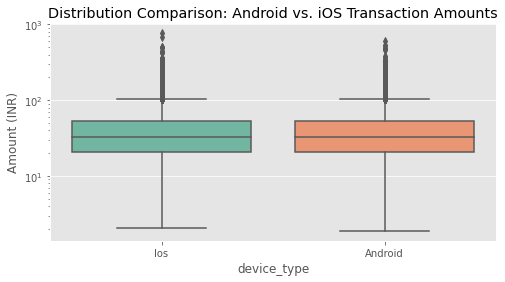

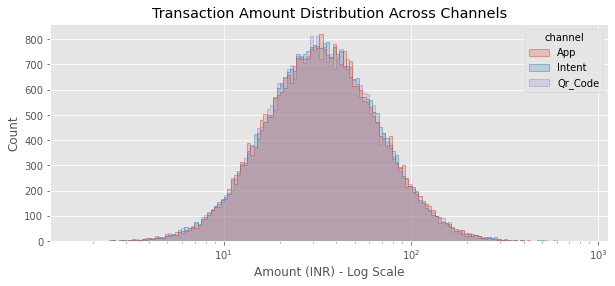

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplot for T-Test: Android vs. iOS Transaction Amounts
plt.figure(figsize=(8, 4))
sns.boxplot(x="device_type", y="amount", data=df_transactions[df_transactions["device_type"].isin(["Android", "Ios"])], palette="Set2")
plt.title("Distribution Comparison: Android vs. iOS Transaction Amounts")
plt.ylabel("Amount (INR)")
plt.yscale("log") # Log scale for right-skewed data
plt.show()

# 2. Histogram / KDE Plot for Channel Distribution
plt.figure(figsize=(10, 4))
sns.histplot(data=df_transactions, x="amount", hue="channel", element="step", common_norm=False, log_scale=True)
plt.title("Transaction Amount Distribution Across Channels")
plt.xlabel("Amount (INR) - Log Scale")
plt.show()

In [30]:
# Extract cleaned arrays
android_vals = df_transactions[df_transactions['device_type'] == 'Android']['amount'].dropna()
ios_vals = df_transactions[df_transactions['device_type'] == 'Ios']['amount'].dropna()

# Calculate means, stds, and standard error of the difference
mean_diff = android_vals.mean() - ios_vals.mean()
n1, n2 = len(android_vals), len(ios_vals)
pooled_se = np.sqrt((android_vals.var(ddof=1)/n1) + (ios_vals.var(ddof=1)/n2))

# 95% Confidence Interval using t-distribution degrees of freedom
dof_ci = n1 + n2 - 2
t_crit = stats.t.ppf(0.975, df=dof_ci)
ci_lower = mean_diff - (t_crit * pooled_se)
ci_upper = mean_diff + (t_crit * pooled_se)

print(f"Mean Difference (Android - iOS): {mean_diff:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

Mean Difference (Android - iOS): -0.1659
95% Confidence Interval: [-0.7671, 0.4354]


### Statistical Assumptions & Limitations

**1. Core Assumptions of Tests Performed:**
* **Normality:** Parametric tests (T-Test, ANOVA, Pearson Correlation) assume that continuous variables (like transaction `amount`) follow a normal distribution. Due to real-world financial data skewness, large sample sizes ($n=100,000$) were relied upon via the Central Limit Theorem.
* **Homogeneity of Variance (Homoscedasticity):** Independent group comparisons assume equal variance across categories (e.g., Android vs. iOS spend variance).
* **Independence of Observations:** Assumes individual transactions are completely independent events generated by separate user interactions.
* **Mutually Exclusive Categories:** Chi-Square tests assume categorical variables (device type vs. status) are distinct and non-overlapping.

**2. Key Limitations:**
* **Skewness & Outliers:** Transaction amounts exhibit a heavy right-skewed distribution with extreme high-value outliers. While mitigated by log scaling and large sample size, parametric metrics can still be sensitive to extreme values.
* **Linearity Constraint:** The Pearson correlation test only evaluates linear relationships. Complex, non-linear fraud behaviors (such as specific cluster patterns or multi-variable thresholds) are not captured by linear coefficients.